# Week 9 - K Nearest Neighbours and K Means
#### Part 2
### Notebook created by Jonathan Penava
By the end of this lesson you should know what K Nearest Neighbour and K means algorithms are and how to use them to classify data points within clusters.

## Overview
- KNN and K Means
- <span style="color:red;">KNN Example</span>
- K Means Example

For our example we are going to use the penguin dataset from Exercise 5

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset('penguins')

In [32]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


What if we want to determine which type of species we are dealing with.  We will use all of our other data to determine our result.

In [33]:
#Possible species
penguins['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

We need to clean and prepare our data by converting all other values into numerical values so that will be island and sex.

In [34]:
#Possible islands
penguins['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [35]:
penguins.replace('Torgersen', 0, inplace=True)
penguins.replace('Biscoe', 1, inplace=True)
penguins.replace('Dream', 2, inplace=True)

penguins.replace('Male', 0, inplace=True)
penguins.replace('Female', 1, inplace=True)

penguins.dropna(axis=0, inplace=True)

In [36]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    int64  
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 20.8+ KB


Doing a pairplot on our data, we are going to colour code our points based on the species of our penguins.

In [37]:
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

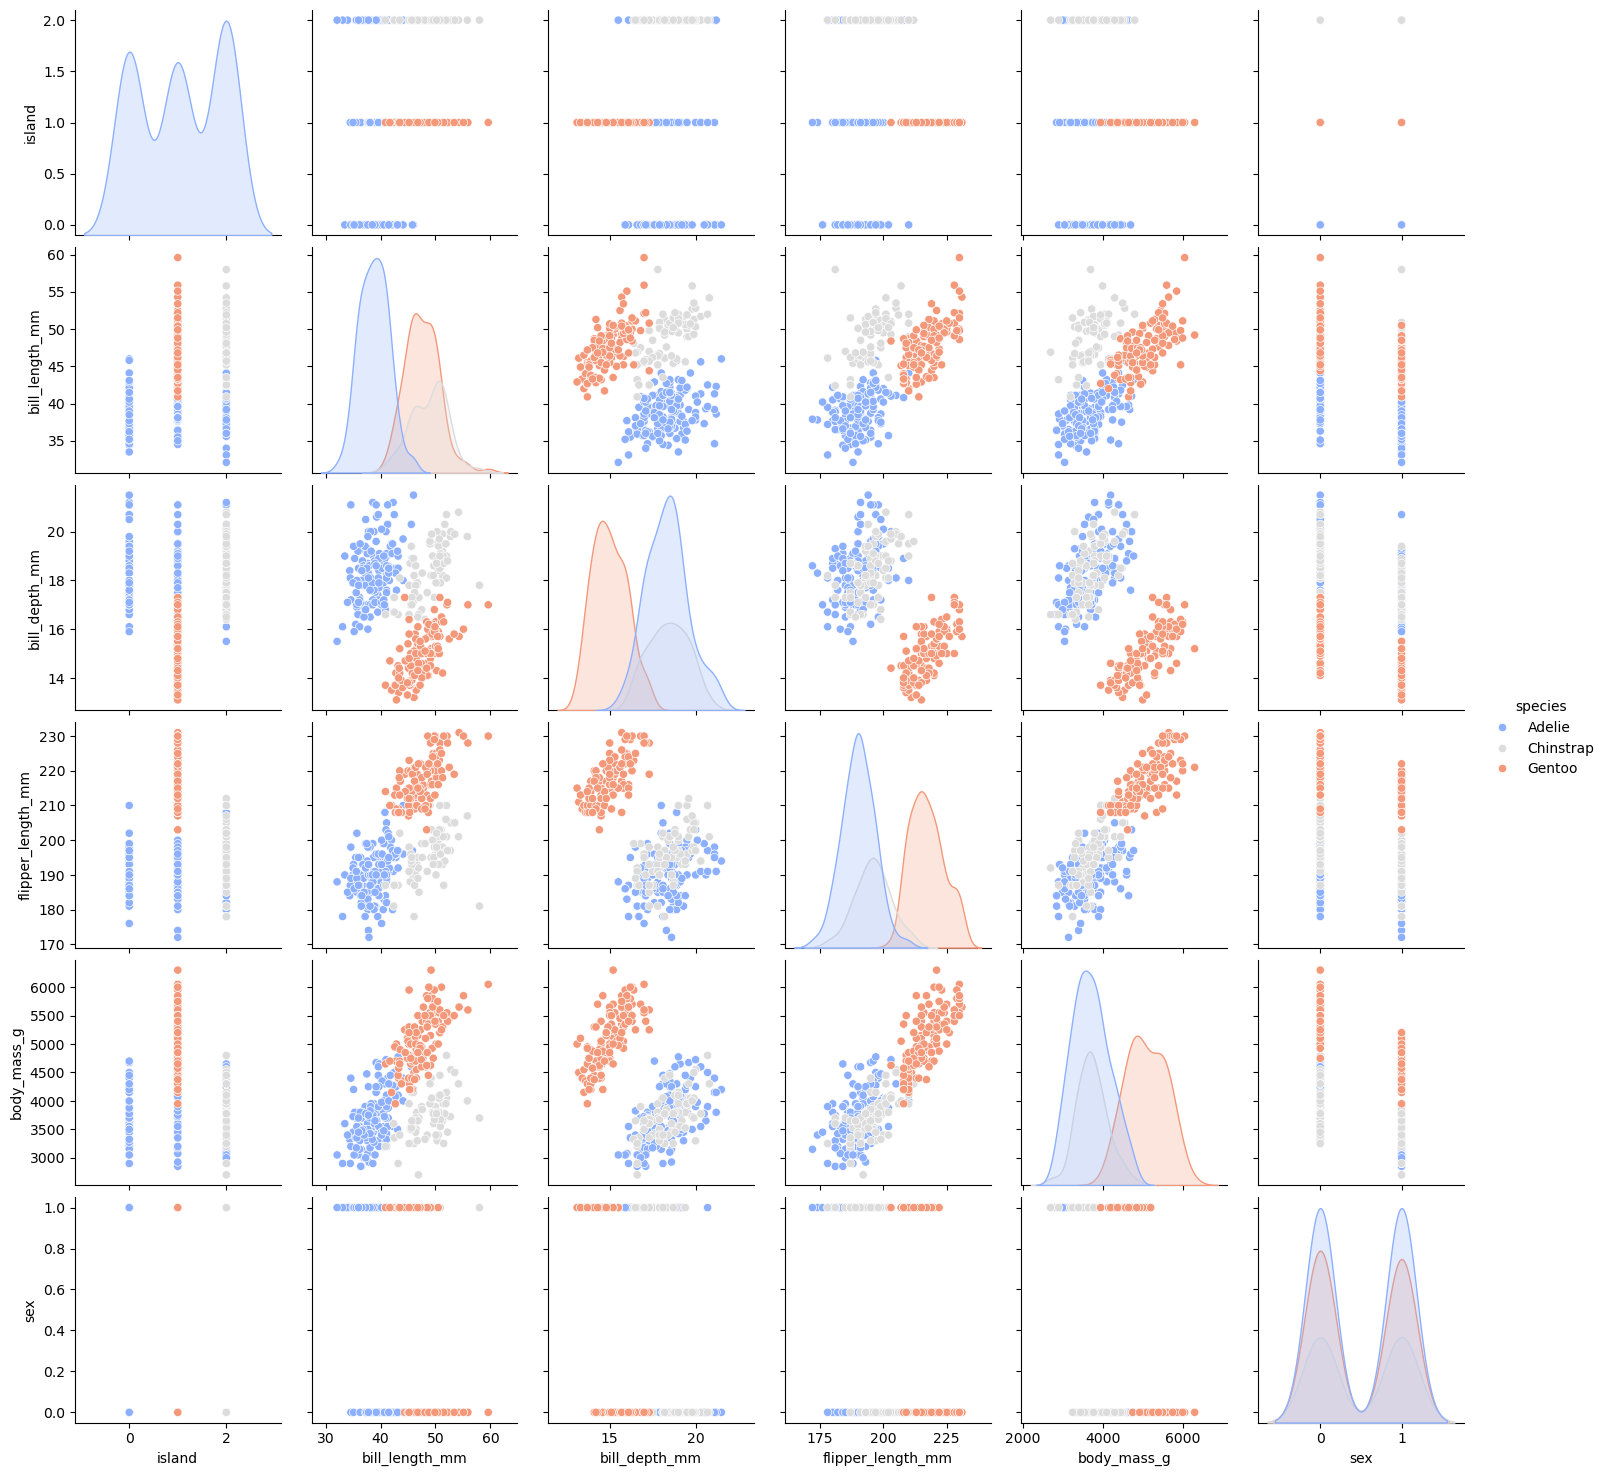

In [38]:
sns.pairplot(penguins,hue='species',palette='coolwarm')

We can see our data clustering based on the species of our penguin.  While there is some overlap in some diagrams, other diagrams show lots of separation.

We now want split our data and train our algorithm.

In [39]:
#Remove the dependent data (our y) from our independent data (our x values)
X, y = penguins.drop('species', axis=1), penguins['species'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

We are going to use KNN to train our algorithm, and we are going to start with K=1

In [46]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

Scoring our result we get

In [41]:
knn.score(X_test, y_test)

0.81

In [42]:
predictions = knn.predict(X_test)

Checking our classification report

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

      Adelie       0.80      0.92      0.86        52
   Chinstrap       0.78      0.37      0.50        19
      Gentoo       0.84      0.90      0.87        29

    accuracy                           0.81       100
   macro avg       0.81      0.73      0.74       100
weighted avg       0.81      0.81      0.79       100



Our model is pretty accurate.  But how does the value of k impact our result?  If we increase k do we increase our accuracy? And what is the best choice for our value of k?

We are going to run our knn classifier on values of k from 1-40.  We are then going to track the error rate of each result.

In [44]:
error_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Graphing our result of error rate to K

Text(0, 0.5, 'Error Rate')

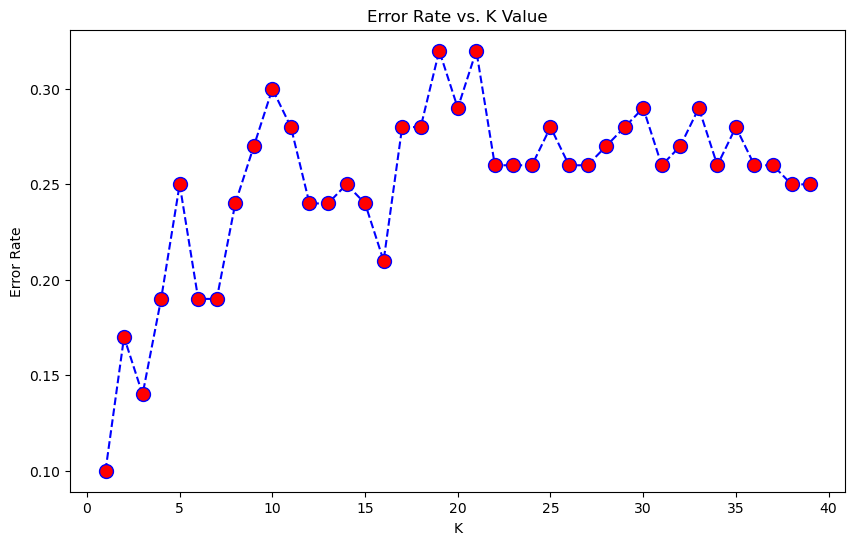

In [45]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In this case we get the lowest error rate at K=1.  If we choose a higher rate then we get a larger magrin of error.  This is not always the case.  In your exercise, you will find a lower error rate with a larger value of k.